In [ ]:
from config import MODEL_CONFIGS
from pathlib import Path
import pandas as pd
from datasets import Dataset
import json
from transformers import AutoTokenizer
from patching import extract_code_blocks, get_code_similarity, get_patch_similarity, apply_generated_patch
from tqdm import tqdm

WORK_DIR = Path.cwd()
DS_TEST_PATH = WORK_DIR / "dataset" / "split" / "test_dataset.jsonl"
ds_test = Dataset.from_pandas(pd.read_json(DS_TEST_PATH, lines=True))
id_to_idx = {item['id']: idx for idx, item in enumerate(ds_test)}

import re
def extract(text):
    return re.findall(r"```(.*?)```", text, re.DOTALL)

def compute_similarity(example: dict, result: dict, test_type: str):

    blocks = extract(result["answer"])

    if test_type == "fine_tuned_patch": 
        # model is fine tuned to output patch
        true_patch = example["diff_patch"]
        patch = blocks[-1] if blocks else ""
        #return get_patch_similarity(patch, true_patch)
        bad_code = example["bad_code"]
        fixed_code, st = apply_generated_patch(bad_code, patch)
        good_code = example["good_code"]
        return get_code_similarity(good_code, fixed_code), st

    else: 
        # model will give full repaired code
        if not blocks:  # Model thinks code is correct
            return 1.0 if example["mutation_category"] == "none" else 0.0
        else:
            good_code = example["good_code"]
            fixed_code = blocks[-1] # assume last block is fixed code
            return get_code_similarity(good_code, fixed_code), True


def present_results(model: str, test_type: str, always_compute: bool = False):

    if test_type not in ["baseline", "rag_only", "fine_tuned_code", "fine_tuned_patch"]:
        raise ValueError("Unknown test type: {test_type}")
    
    if model not in MODEL_CONFIGS:
        raise ValueError(
            f"Unknown model '{model}'. "
            f"Available models: {list(MODEL_CONFIGS.keys())}"
        )

    cfg = MODEL_CONFIGS[model]
    model_name = cfg["model_name"]
    model_short = model_name.split("/")[1]
        
    RESULTS_DIR = WORK_DIR / "results" / "testing" / model_short / test_type / "test_results.json"
    

    # Load results
    with open(RESULTS_DIR) as f:
        results = json.load(f)

    doms, syns, nones, toks = [], [], [], []

    editing = False
    tokenizer = None

    pbar = tqdm(results, desc="Computing results")

    passed_sum = 0
    passed_count = 0
    failed_to_apply = 0
    
    for result in pbar:
        id = result["id"]
        answer = result["answer"]
        idx = id_to_idx[id]
        category = ds_test[idx]["mutation_category"]
        mut_type = ds_test[idx]["mutation_type"]

        passed = result.get("passed", None)
        token_len = result.get("token_len", None)

        if always_compute or passed is None:
            if not editing:
                editing = True

            sim, st = compute_similarity(ds_test[idx], result, test_type)
            passed = 1 if sim == 1.0 else 0

            if not st:
                failed_to_apply += 1


            result["mutation_category"] = category
            result["mutation_type"] = mut_type
            result["similarity"] = sim
            result["passed"] = passed

        if always_compute or token_len is None:
            if not editing:
                editing = True

            if tokenizer is None:
                tokenizer = AutoTokenizer.from_pretrained(
                    model_name, trust_remote_code=True
                )

            token_len = len(tokenizer.encode(answer, add_special_tokens=True))
            result["token_len"] = token_len

        toks.append(token_len)

        if passed is not None:
            passed_sum += passed
            passed_count += 1
            pbar.set_postfix(
                last=passed,
                avg=round(passed_sum / passed_count, 4)
        )

        if category == "domain":
            doms.append(passed)
        elif category == "syntax":
            syns.append(passed)
        elif category == "none":
            nones.append(passed)

    dom_score = sum(doms) / len(doms) if len(doms) != 0 else None
    syn_score = sum(syns) / len(syns) if len(syns) != 0 else None
    none_score = sum(nones) / len(nones) if len(nones) != 0 else None

    if dom_score and syn_score and none_score:
        overall_score = (dom_score+syn_score+none_score)/3
    else:
        overall_score = None

    tok_len_avg = int(sum(toks) / len(toks))

    print(f"Performance for {model_short}, {test_type}:")
    print(f"Syntax: {syn_score} (n={len(syns)})")
    print(f"Domain: {dom_score} (n={len(doms)})")
    print(f"Correct: {none_score} (n={len(nones)})")
    print(f"Overall: {overall_score}")
    print(f"Avg Generated Tokens: {tok_len_avg}\n")
    print(f"Patches failed to be applied: {failed_to_apply}")

    if editing:
        with open(RESULTS_DIR, 'w') as f:
            json.dump(results, f, indent=2)

In [6]:
with open("results//testing//Qwen2.5-Coder-1.5B-Instruct//fine_tuned_code//test_results.json") as f:
    results = json.load(f)

In [20]:
import re
def extract(text):
    return re.findall(r"```(.*?)```", text, re.DOTALL)

In [24]:
print(ds_test[0]["good_code"])
print(results[0]["mutation_category"])
print(extract(results[0]["answer"])[0])

package Vehicle_Remix_0039_c0ad {
    port def LugNutCompositePort;
    port def FuelPort;
    part def FuelPort_Def { port p : FuelPort; }
    part def FuelPort_Def { port p : FuelPort; }
    part def LugNutCompositePort_Distractor_Def { port p : LugNutCompositePort; }
    part def SubSystem_Context {
        part comp_a_8631 : FuelPort_Def;
        part comp_b_83e6 : FuelPort_Def;
        part comp_distractor_5223 : LugNutCompositePort_Distractor_Def;
        connect comp_a_8631.p to comp_b_83e6.p;
    }
}
none
package Vehicle_Remix_0039_c0ad {
    port def LugNutCompositePort;
    port def FuelPort;
    part def FuelPort_Def { port p : FuelPort; }
    part def FuelPort_Def { port p : FuelPort; }
    part def LugNutCompositePort_Distractor_Def { port p : LugNutCompositePort; }
    part def SubSystem_Context {
        part comp_a_8631 : FuelPort_Def;
        part comp_b_83e6 : FuelPort_Def;
        part comp_distractor_5223 : LugNutCompositePort_Distractor_Def;
        connect comp_a_

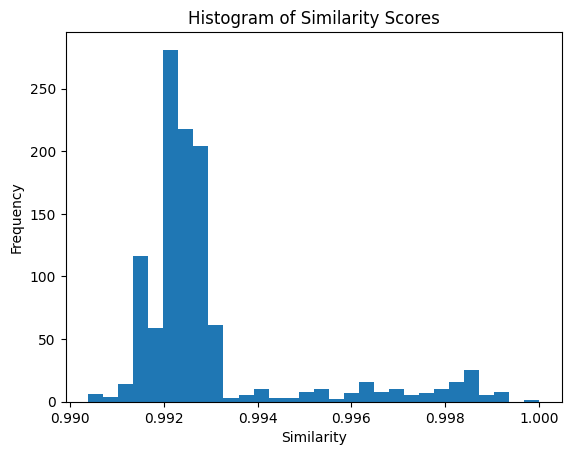

In [7]:
import matplotlib.pyplot as plt

sims = []
for result in results:
    if result["similarity"] > 0.99:
        sims.append(result["similarity"])

plt.hist(sims, bins=30)
plt.xlabel("Similarity")
plt.ylabel("Frequency")
plt.title("Histogram of Similarity Scores")
plt.show()


In [2]:
present_results(model="qwen_coder_1p5b", test_type="baseline", always_compute=True)

Computing results: 100%|██████████| 1172/1172 [00:05<00:00, 213.35it/s, avg=0.0486, last=0]


Performance for Qwen2.5-Coder-1.5B-Instruct, baseline:
Syntax: 0.06056860321384425 (n=809)
Domain: 0.0 (n=161)
Correct: 0.039603960396039604 (n=202)
Overall: None
Avg Generated Tokens: 424



In [3]:
present_results(model="qwen_coder_1p5b", test_type="rag_only", always_compute=True)

Computing results: 100%|██████████| 363/363 [00:02<00:00, 176.81it/s, avg=0.0441, last=0]


Performance for Qwen2.5-Coder-1.5B-Instruct, rag_only:
Syntax: None (n=0)
Domain: 0.006211180124223602 (n=161)
Correct: 0.07425742574257425 (n=202)
Overall: None
Avg Generated Tokens: 495



In [11]:
present_results(model="qwen_coder_1p5b", test_type="fine_tuned_code", always_compute=True)

Computing results: 100%|██████████| 1172/1172 [00:04<00:00, 289.20it/s, avg=0.0009, last=0]


Performance for Qwen2.5-Coder-1.5B-Instruct, fine_tuned_code:
Syntax: 0.0012360939431396785 (n=809)
Domain: 0.0 (n=161)
Correct: 0.0 (n=202)
Overall: None
Avg Generated Tokens: 210

Patches failed to be applied: 0


In [10]:
present_results(model="qwen_coder_1p5b", test_type="fine_tuned_patch", always_compute=True)

Computing results:   0%|          | 0/1172 [00:00<?, ?it/s]

Computing results: 100%|██████████| 1172/1172 [00:34<00:00, 34.15it/s, avg=0.588, last=0]


Performance for Qwen2.5-Coder-1.5B-Instruct, fine_tuned_patch:
Syntax: 0.5710754017305315 (n=809)
Domain: 0.16149068322981366 (n=161)
Correct: 0.995049504950495 (n=202)
Overall: 0.5758718633036134
Avg Generated Tokens: 69

Patches failed to be applied: 333


In [6]:
print(ds_test[2]["diff_patch"])

@@ -9,6 +9,6 @@
         part comp_a_96e6 : LugNutCompositePort_Def;
         part comp_b_bffa : LugNutPort_Def;
         part comp_distractor_2adb : ShaftPort_b_Distractor_Def;
-        connect comp_a_96e6.p to comp_distractor_2adb.p;
+        connect comp_a_96e6.p to comp_b_bffa.p;
     }
 }


In [26]:
def compile_chat(example, training_type):
    """Compile chat messages from prompts and responses."""

    if training_type == "code": # output code
        resp = example["good_code"]
    else: # output diff patch
        resp = example["diff_patch"]

    bad_code = example["bad_code"]

    category = example["mutation_category"]
    prompt = example["prompt"]

    if category == "syntax":
        domain_rules = ""
    else: 
        domain_rules = "Use the following rules to identify any domain mistakes\n\n### Domain Rules:\n" + example["domain_rules"]

    # rules are always added during training
    chat = [
        {"role": "user", "content": "You are a SysML v2 expert."}, 
        {"role": "user", "content": prompt + domain_rules + f"\n\n### Code: \n```{bad_code}```"},
        {"role": "assistant", "content": f"```{resp}```"}
    ]

    return {"messages": chat}



ds_test = ds_test.map(
    lambda example: compile_chat(example, training_type="patch"),
    batched=False,
)

Map:   0%|          | 0/1172 [00:00<?, ? examples/s]

In [34]:
print(ds_test[8]["messages"][1]["content"])

Analyze and repair the following SysML v2 code if there are any potential domain inconsistencies or mistakes.
Use the following rules to identify any domain mistakes

### Domain Rules:
- 'FuelPort' belongs to Domain: fluid_fuel
- 'LugNutPort' belongs to Domain: mechanical_fastening

Valid Connections Rules:
- fluid_fuel can ONLY connect to: ['fluid_fuel']
- mechanical_fastening can ONLY connect to: ['mechanical_fastening']

### Code: 
```package Vehicle_Remix_0929_aad6 {
    port def LugNutPort;
    port def FuelPort;
    part def FuelPort_Def { port p : FuelPort; }
    part def FuelPort_Def { port p : FuelPort; }
    part def LugNutPort_Distractor_Def { port p : LugNutPort; }
    part def SubSystem_Context {
        part comp_a_2b93 : FuelPort_Def;
        part comp_b_f528 : FuelPort_Def;
        part comp_distractor_6814 : LugNutPort_Distractor_Def;
        connect comp_a_2b93.p to comp_distractor_6814.p;
    }
}```


In [ ]:
Overall performance for baseline is:
Domain: 0.0061 (n=163)
Syntax: 0.1759 (n=790)
None: 0.2706 (n=462)
Overall: 0.1509

Overall performance with RAG is:
Domain: 0.0798 (n=163)
Syntax: 0.1759 (n=790)
None: 0.3333 (n=462)
Overall: 0.1963

In [ ]:
losses, epochs = [], []
for result in results:
    loss = result.get("eval_loss", None)
    if not loss:
        continue
    epoch = result.get("epoch", None)
    
    losses.append(loss)
    epochs.append(epoch)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linewidth=2, markersize=4, color='#2E86AB')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Evaluation Loss over Training Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()